In [1]:
# ==================================================
# XGBoost - Baseline
# ==================================================

import os
import sys
import joblib
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


# ==================================================
# Configuração do projeto
# ==================================================

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.preprocessing import create_preprocessor


# ==================================================
# Leitura dos dados
# ==================================================

TARGET = "default payment next month"

df = pd.read_excel(
    r"C:\Users\T-Gamer\Desktop\igor\credit-default-api\data\raw\default_of_credit_card_clients.xls",
    header=1
)


# ==================================================
# Separação entre features e target
# ==================================================

X = df.drop(columns=["ID", TARGET])

y = df[TARGET]


print("=" * 60)
print("Dataset")
print("=" * 60)

print(f"Número de observações : {df.shape[0]}")
print(f"Número de variáveis   : {X.shape[1]}")


# ==================================================
# Train Test Split
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


print("\nTreino:", X_train.shape)
print("Teste :", X_test.shape)


# ==================================================
# Pré-processamento
# ==================================================

preprocessor = create_preprocessor()


# ==================================================
# Pipeline
# ==================================================

pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                subsample=1.0,
                colsample_bytree=1.0,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# ==================================================
# Treinamento
# ==================================================

print("\n" + "=" * 60)
print("Treinamento - XGBoost Baseline")
print("=" * 60)

pipeline.fit(
    X_train,
    y_train
)


# ==================================================
# Predições - Teste
# ==================================================

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:, 1]


# ==================================================
# Predições - Treino
# ==================================================

y_train_pred = pipeline.predict(X_train)

y_train_prob = pipeline.predict_proba(X_train)[:, 1]


# ==================================================
# Métricas - Teste
# ==================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


# ==================================================
# Métricas - Treino
# ==================================================

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

train_roc_auc = roc_auc_score(
    y_train,
    y_train_prob
)


# ==================================================
# Resultados - Teste
# ==================================================

print("\n" + "=" * 60)
print("RESULTADOS - TESTE")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")


# ==================================================
# Resultados - Treino
# ==================================================

print("\n" + "=" * 60)
print("RESULTADOS - TREINO")
print("=" * 60)

print(f"Accuracy : {train_accuracy:.4f}")
print(f"ROC AUC  : {train_roc_auc:.4f}")


# ==================================================
# Generalização
# ==================================================

accuracy_gap = train_accuracy - accuracy

roc_auc_gap = train_roc_auc - roc_auc


print("\n" + "=" * 60)
print("GENERALIZAÇÃO")
print("=" * 60)

print(f"Gap Accuracy : {accuracy_gap:.4f}")
print(f"Gap ROC AUC  : {roc_auc_gap:.4f}")


# ==================================================
# Classification Report
# ==================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ==================================================
# Confusion Matrix
# ==================================================

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# ==================================================
# Salva modelo
# ==================================================

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models",
    "xgboost_baseline_pipeline.pkl"
)

joblib.dump(
    pipeline,
    MODEL_PATH
)

print("\nModelo salvo com sucesso!")
print(f"Local: {MODEL_PATH}")

Dataset
Número de observações : 30000
Número de variáveis   : 23

Treino: (24000, 23)
Teste : (6000, 23)

Treinamento - XGBoost Baseline

RESULTADOS - TESTE
Accuracy : 0.8183
Precision: 0.6626
Recall   : 0.3640
F1-score : 0.4698
ROC AUC  : 0.7731

RESULTADOS - TREINO
Accuracy : 0.8478
ROC AUC  : 0.8725

GENERALIZAÇÃO
Gap Accuracy : 0.0294
Gap ROC AUC  : 0.0995

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000


CONFUSION MATRIX
[[4427  246]
 [ 844  483]]

Modelo salvo com sucesso!
Local: c:\Users\T-Gamer\Desktop\igor\credit-default-api\models\xgboost_baseline_pipeline.pkl


In [2]:
# ==================================================
# Diagnóstico - XGBoost Baseline
# ==================================================

print("=" * 60)
print("TREINO")
print("=" * 60)

print(f"Accuracy : {train_accuracy:.4f}")
print(f"ROC AUC  : {train_roc_auc:.4f}")

print("\n" + "=" * 60)
print("TESTE")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\n" + "=" * 60)
print("GENERALIZAÇÃO")
print("=" * 60)

print(f"Gap Accuracy : {accuracy_gap:.4f}")
print(f"Gap ROC AUC  : {roc_auc_gap:.4f}")

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(confusion_matrix(y_test, y_pred))

TREINO
Accuracy : 0.8478
ROC AUC  : 0.8725

TESTE
Accuracy : 0.8183
Precision: 0.6626
Recall   : 0.3640
F1-score : 0.4698
ROC AUC  : 0.7731

GENERALIZAÇÃO
Gap Accuracy : 0.0294
Gap ROC AUC  : 0.0995

CONFUSION MATRIX
[[4427  246]
 [ 844  483]]


In [3]:
# ============================================================
# XGBoost - Grid Search
# ============================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
import joblib


# ============================================================
# 1. Cross-validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 2. Modelo base
# ============================================================

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 3. Pipeline
# ============================================================

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb)
])


# ============================================================
# 4. Grid de hiperparâmetros
# ============================================================

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__min_child_weight": [1, 5],
    "classifier__subsample": [0.8],
    "classifier__colsample_bytree": [0.8],
    "classifier__reg_lambda": [1, 5]
}

In [4]:
# ============================================================
# 5. Grid Search
# ============================================================

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)


print("Iniciando Grid Search...")
grid_search.fit(X_train, y_train)

print("\nGrid Search concluído.")

Iniciando Grid Search...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Grid Search concluído.


In [5]:
# ============================================================
# 6. Melhores resultados
# ============================================================

print("\n" + "=" * 60)
print("XGBOOST - GRID SEARCH")
print("=" * 60)

print("\nMelhores hiperparâmetros:")
print(grid_search.best_params_)

print("\nMelhor ROC AUC médio - Cross Validation:")
print(f"{grid_search.best_score_:.4f}")


XGBOOST - GRID SEARCH

Melhores hiperparâmetros:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 100, 'classifier__reg_lambda': 5, 'classifier__subsample': 0.8}

Melhor ROC AUC médio - Cross Validation:
0.7853


In [6]:
# ============================================================
# 6. Melhores resultados
# ============================================================

print("\n" + "=" * 60)
print("XGBOOST - GRID SEARCH")
print("=" * 60)

print("\nMelhores hiperparâmetros:")
print(grid_search.best_params_)

print("\nMelhor ROC AUC médio - Cross Validation:")
print(f"{grid_search.best_score_:.4f}")


XGBOOST - GRID SEARCH

Melhores hiperparâmetros:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 100, 'classifier__reg_lambda': 5, 'classifier__subsample': 0.8}

Melhor ROC AUC médio - Cross Validation:
0.7853


In [7]:
# ============================================================
# 7. Melhor modelo
# ============================================================

best_xgb = grid_search.best_estimator_


# ============================================================
# 8. Predições
# ============================================================

y_pred_train = best_xgb.predict(X_train)
y_pred_test = best_xgb.predict(X_test)

y_proba_train = best_xgb.predict_proba(X_train)[:, 1]
y_proba_test = best_xgb.predict_proba(X_test)[:, 1]

In [8]:
# ============================================================
# 9. Função de avaliação
# ============================================================

def evaluate_model(y_true, y_pred, y_proba, dataset_name):
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)

    print(f"\n{'=' * 60}")
    print(dataset_name)
    print(f"{'=' * 60}")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }


train_metrics = evaluate_model(
    y_train,
    y_pred_train,
    y_proba_train,
    "TREINO"
)

test_metrics = evaluate_model(
    y_test,
    y_pred_test,
    y_proba_test,
    "TESTE"
)


TREINO
Accuracy : 0.8408
Precision: 0.7600
Recall   : 0.4099
F1-score : 0.5326
ROC AUC  : 0.8483

TESTE
Accuracy : 0.8173
Precision: 0.6620
Recall   : 0.3557
F1-score : 0.4627
ROC AUC  : 0.7770


In [9]:
# ============================================================
# 10. Generalização
# ============================================================

accuracy_gap = (
    train_metrics["accuracy"] -
    test_metrics["accuracy"]
)

roc_auc_gap = (
    train_metrics["roc_auc"] -
    test_metrics["roc_auc"]
)

print("\n" + "=" * 60)
print("GENERALIZAÇÃO")
print("=" * 60)

print(f"Accuracy - Treino: {train_metrics['accuracy']:.4f}")
print(f"Accuracy - Teste : {test_metrics['accuracy']:.4f}")
print(f"Accuracy Gap     : {accuracy_gap:.4f}")

print()

print(f"ROC AUC - Treino: {train_metrics['roc_auc']:.4f}")
print(f"ROC AUC - Teste : {test_metrics['roc_auc']:.4f}")
print(f"ROC AUC Gap     : {roc_auc_gap:.4f}")


GENERALIZAÇÃO
Accuracy - Treino: 0.8408
Accuracy - Teste : 0.8173
Accuracy Gap     : 0.0235

ROC AUC - Treino: 0.8483
ROC AUC - Teste : 0.7770
ROC AUC Gap     : 0.0712


In [10]:
# ============================================================
# 11. Classification Report
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - TESTE")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=[
            "Adimplente",
            "Inadimplente"
        ]
    )
)


CLASSIFICATION REPORT - TESTE
              precision    recall  f1-score   support

  Adimplente       0.84      0.95      0.89      4673
Inadimplente       0.66      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [11]:
# ============================================================
# 12. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred_test)

print("\n" + "=" * 60)
print("CONFUSION MATRIX - TESTE")
print("=" * 60)

print(cm)


CONFUSION MATRIX - TESTE
[[4432  241]
 [ 855  472]]


In [16]:
# ============================================================
# 13. Salvando o melhor modelo
# ============================================================

model_path = "../models/xgboost_tuned_pipeline.pkl"

joblib.dump(
    best_xgb,
    model_path
)

print(f"\nModelo salvo em: {model_path}")


Modelo salvo em: ../models/xgboost_tuned_pipeline.pkl


In [17]:
# ============================================================
# FEATURE IMPORTANCE - XGBOOST TUNED
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Acessando o pré-processador e o classificador
# ============================================================

preprocessor = best_xgb.named_steps["preprocessor"]
xgb_model = best_xgb.named_steps["classifier"]


# ============================================================
# 2. Obtendo os nomes das features após o pré-processamento
# ============================================================

feature_names = preprocessor.get_feature_names_out()


# ============================================================
# 3. Obtendo as importâncias
# ============================================================

importances = xgb_model.feature_importances_


# ============================================================
# 4. Criando DataFrame
# ============================================================

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})


# ============================================================
# 5. Ordenando da maior para a menor importância
# ============================================================

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 6. Exibindo as principais features
# ============================================================

print("\n" + "=" * 60)
print("XGBOOST TUNED - FEATURE IMPORTANCE")
print("=" * 60)

print(
    feature_importance_df.head(20).to_string(index=False)
)


XGBOOST TUNED - FEATURE IMPORTANCE
         feature  importance
      ord__PAY_0    0.436087
      ord__PAY_2    0.139475
      ord__PAY_3    0.044871
      ord__PAY_4    0.038218
      ord__PAY_5    0.030312
      ord__PAY_6    0.020805
      cat__SEX_2    0.018907
cat__EDUCATION_5    0.017722
   num__PAY_AMT2    0.017314
  num__LIMIT_BAL    0.016474
  num__BILL_AMT1    0.016049
   num__PAY_AMT3    0.014190
 cat__MARRIAGE_2    0.012389
  num__BILL_AMT2    0.012250
   num__PAY_AMT1    0.012104
   num__PAY_AMT6    0.011516
   num__PAY_AMT4    0.011233
 cat__MARRIAGE_0    0.011113
  num__BILL_AMT4    0.011038
  num__BILL_AMT3    0.010882


In [19]:
# ============================================================
# 8. Salvando Feature Importance
# ============================================================

feature_importance_df.to_csv(
    "../models/xgboost_tuned_feature_importance.csv",
    index=False
)

print(
    "\nFeature Importance salva em:"
    " ../models/xgboost_tuned_feature_importance.csv"
)


Feature Importance salva em: ../models/xgboost_tuned_feature_importance.csv


In [20]:
# ============================================================
# SHAP - XGBOOST TUNED
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Acessando componentes do pipeline
# ============================================================

preprocessor = best_xgb.named_steps["preprocessor"]
xgb_model = best_xgb.named_steps["classifier"]


# ============================================================
# 2. Transformando o conjunto de teste
# ============================================================

X_test_transformed = preprocessor.transform(X_test)


print("Shape original :", X_test.shape)
print("Shape transformado:", X_test_transformed.shape)

Shape original : (6000, 23)
Shape transformado: (6000, 33)


In [21]:
# ============================================================
# 3. Amostra para SHAP
# ============================================================

SHAP_SAMPLE_SIZE = 1500

rng = np.random.default_rng(42)

sample_indices = rng.choice(
    X_test_transformed.shape[0],
    size=SHAP_SAMPLE_SIZE,
    replace=False
)

X_shap = X_test_transformed[sample_indices]

print("Amostra utilizada para SHAP:", X_shap.shape)

Amostra utilizada para SHAP: (1500, 33)


In [22]:
# ============================================================
# 4. TreeExplainer
# ============================================================

explainer = shap.TreeExplainer(
    xgb_model
)

print("TreeExplainer criado com sucesso.")

# ============================================================
# 5. Valores SHAP
# ============================================================

shap_values = explainer.shap_values(X_shap)

print("Shape dos valores SHAP:", shap_values.shape)

TreeExplainer criado com sucesso.
Shape dos valores SHAP: (1500, 33)


In [23]:
# ============================================================
# 6. Nomes das features
# ============================================================

feature_names = preprocessor.get_feature_names_out()

print("Número de features:", len(feature_names))
print(feature_names)

Número de features: 33
['num__LIMIT_BAL' 'num__AGE' 'num__BILL_AMT1' 'num__BILL_AMT2'
 'num__BILL_AMT3' 'num__BILL_AMT4' 'num__BILL_AMT5' 'num__BILL_AMT6'
 'num__PAY_AMT1' 'num__PAY_AMT2' 'num__PAY_AMT3' 'num__PAY_AMT4'
 'num__PAY_AMT5' 'num__PAY_AMT6' 'cat__SEX_1' 'cat__SEX_2'
 'cat__EDUCATION_0' 'cat__EDUCATION_1' 'cat__EDUCATION_2'
 'cat__EDUCATION_3' 'cat__EDUCATION_4' 'cat__EDUCATION_5'
 'cat__EDUCATION_6' 'cat__MARRIAGE_0' 'cat__MARRIAGE_1' 'cat__MARRIAGE_2'
 'cat__MARRIAGE_3' 'ord__PAY_0' 'ord__PAY_2' 'ord__PAY_3' 'ord__PAY_4'
 'ord__PAY_5' 'ord__PAY_6']


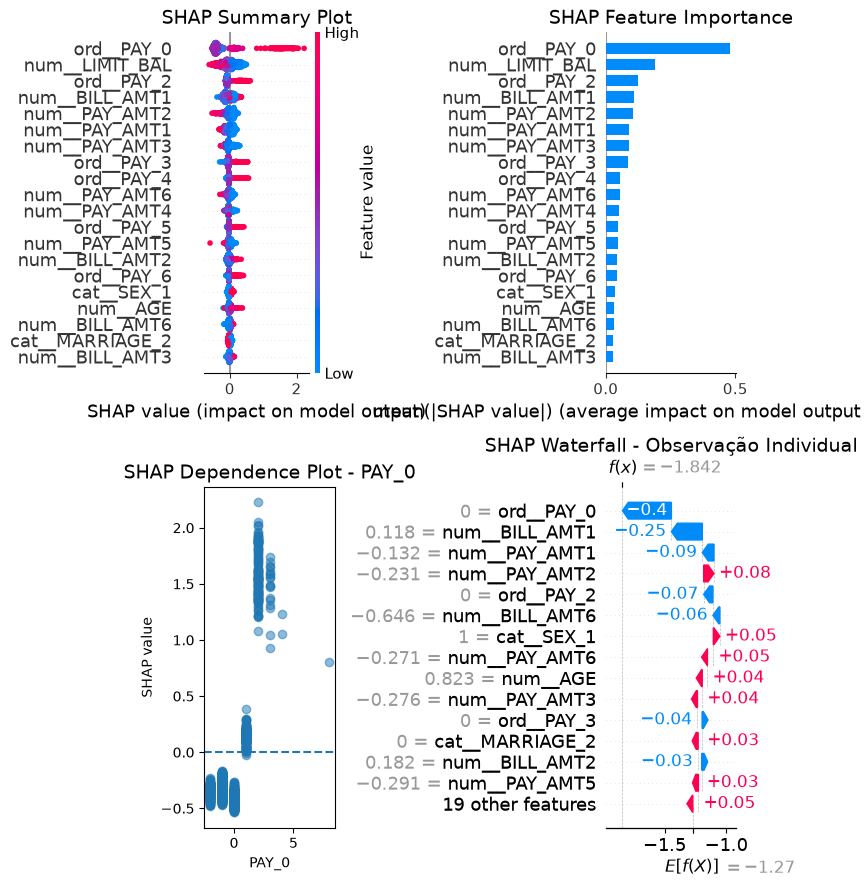

In [33]:
# ============================================================
# SHAP - PAINEL COM OS 4 GRÁFICOS
# ============================================================

import matplotlib.pyplot as plt
import shap


fig, axes = plt.subplots(
    2,
    2,
    figsize=(20, 14)
)

# ============================================================
# 1. SHAP Summary Plot
# ============================================================

plt.sca(axes[0, 0])

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

axes[0, 0].set_title(
    "SHAP Summary Plot",
    fontsize=14
)


# ============================================================
# 2. SHAP Bar Plot
# ============================================================

plt.sca(axes[0, 1])

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

axes[0, 1].set_title(
    "SHAP Feature Importance",
    fontsize=14
)

# ============================================================
# SHAP Dependence Plot - PAY_0
# ============================================================

axes[1, 0].scatter(
    X_shap[:, pay_0_index],
    shap_values[:, pay_0_index],
    alpha=0.5
)

axes[1, 0].axhline(
    y=0,
    linestyle="--"
)

axes[1, 0].set_xlabel("PAY_0")
axes[1, 0].set_ylabel("SHAP value")
axes[1, 0].set_title(
    "SHAP Dependence Plot - PAY_0",
    fontsize=14
)
# ============================================================
# 4. SHAP Waterfall
# ============================================================

plt.sca(axes[1, 1])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[observation_index],
        base_values=explainer.expected_value,
        data=observation,
        feature_names=feature_names
    ),
    max_display=15,
    show=False
)

axes[1, 1].set_title(
    "SHAP Waterfall - Observação Individual",
    fontsize=14
)


# ============================================================
# Ajustes finais
# ============================================================

plt.tight_layout()

plt.show()